# VLST — Unified model comparison (`results.ipynb`)

Consolidates **best configurations** from `advanced.ipynb` and `tabpfn.ipynb` with the six **baseline** learners (LR, RF, XGB, CatBoost, LGBM, TabPFN).

| Protocol | Setting |
|----------|---------|
| **Split** | **70% train · 30% test** (stratified, `RANDOM_STATE=42`) — **same as `tabpfn.ipynb`** |
| **Calibration** | **15% of train** held out for advanced blend weights + classical thresholds (`advanced.ipynb` style) |
| **Classical CV** | 5-fold stratified K-fold on train (**trees/boosters only** — TabPFN excluded; its OOF is not comparable) |
| **TabPFN threshold** | Max F2 on **10-fold OOF train** scores (`tabpfn.ipynb` §5) |
| **Classical threshold** | Max F2 on **calibration** scores |
| **Data** | **One cleaned row set** → scaled (OHE) view for boosters + raw TabPFN view |

**Model families**
- *Baselines*: `lr`, `rf`, `cat`, `xgb`, `lgb`, `tabpfn`
- *Advanced extras*: `rf_b`, `xgb_b`; SLSQP blends on cal (`adv_*`)
- *TabPFN extras*: OOF-learned blends (`tabpfn_blend_*`, `tabpfn_stacking_lr`)

---

## Running on Kaggle

1. **New notebook** → enable **GPU T4** + **Internet**.
2. Add dataset [vlst-data](https://www.kaggle.com/datasets/amirmahdidaraei/vlst-data).
3. Secrets: `TABPFN_TOKEN` (+ optional `HF_TOKEN`).
4. **Run All** → outputs in `/kaggle/working/modeling_results/`.

In [1]:
import importlib.util as _il

_optional = []
for _pkg, _mod in [("optuna", "optuna"), ("tabpfn", "tabpfn")]:
    if _il.find_spec(_mod) is None:
        _optional.append(_pkg)
if _optional:
    %pip install -q --no-warn-conflicts {" ".join(_optional)}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.1/303.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib.util as _il
import json
import os
import re
import warnings
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from scipy.optimize import minimize as scipy_minimize
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 11, "axes.labelsize": 10})

RANDOM_STATE = 42
TEST_SIZE = 0.30              # match tabpfn.ipynb (70% train / 30% test)
FRAC_CAL = 0.15               # cal slice from train for advanced blends + classical thresholds
N_CV_FOLDS = 5                # classical CV only (TabPFN excluded — context model)
THRESHOLD_CV_SPLITS = 10      # TabPFN OOF folds for threshold (tabpfn.ipynb §5)
THRESHOLD_BETA = 2.0
BLEND_N_SPLITS = 5            # OOF folds for tabpfn-style blend weights
BLEND_OPTUNA_TRIALS = 200

TARGET_COL = "Stent thrombosis"
ID_COLS = ["NO.", "Name"]
LEAKAGE_COLS = ["Time since stent implantation"]
STENT_BRAND_RAW_COL = "Stent type-SES"
STENT_BRAND_COL = "stent_brand"
STENT_TYPE_FLAG_COLS = ["PES", "ZES", "EVS"]
STENT_BRAND_MIN_COUNT = 30

ADV_MEMBERS = ["cat", "xgb", "rf", "rf_b", "xgb_b", "lgb", "lr"]
TABPFN_BLEND_MEMBERS = ["tabpfn", "lr", "rf", "cat", "xgb", "lgb"]

KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_RESULT_SUBDIR = "modeling_results"
is_kaggle_env = os.path.isdir("/kaggle/working")


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above cwd.")


def _discover_vlst_csv() -> Path:
    env = os.environ.get("VLST_RAW_CSV")
    if env and Path(env).is_file():
        return Path(env)
    for p in (
        Path(KAGGLE_RAW_CSV),
        Path("/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"),
        Path("/kaggle/input/vlst-data/VLST.csv"),
    ):
        if p.is_file():
            return p
    base = Path("/kaggle/input")
    if base.is_dir():
        for p in base.rglob("VLST.csv"):
            if p.is_file():
                return p
    raise FileNotFoundError(
        "VLST.csv not found. On Kaggle, add the vlst-data dataset or set VLST_RAW_CSV."
    )


def _resolve_paths():
    if is_kaggle_env:
        raw = _discover_vlst_csv()
        result = Path(
            os.environ.get(
                "VLST_RESULT_DIR",
                str(Path("/kaggle/working") / KAGGLE_RESULT_SUBDIR),
            )
        )
        return raw, result, "Kaggle"
    repo = _find_repo_root()
    return (
        Path(os.environ.get("VLST_RAW_CSV", repo / "data" / "raw" / "VLST.csv")),
        Path(os.environ.get("VLST_RESULT_DIR", repo / "data" / "result" / "modeling_results")),
        "local",
    )


RAW_PATH, RESULT_DIR, _runtime = _resolve_paths()
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# GPU for boosters / TabPFN (matches advanced.ipynb + tabpfn.ipynb on Kaggle)
try:
    import torch

    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "cpu"
except Exception:
    CUDA_AVAILABLE = False
    DEVICE_NAME = "cpu"

CATBOOST_TASK_TYPE = "GPU" if CUDA_AVAILABLE else "CPU"
XGB_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
LGB_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"

print("Runtime:", _runtime)
print("RAW_PATH:", RAW_PATH)
print("RESULT_DIR:", RESULT_DIR)
print("CUDA:", CUDA_AVAILABLE, "|", DEVICE_NAME)
print("CatBoost:", CATBOOST_TASK_TYPE, "| XGB:", XGB_DEVICE)

Runtime: Kaggle
RAW_PATH: /kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv
RESULT_DIR: /kaggle/working/modeling_results
CUDA: True | Tesla T4
CatBoost: GPU | XGB: cuda


## 1. Load data — one cleaned row set, dual views (scaled + raw TabPFN)

In [3]:
def _canonicalize_stent_brand(value):
    if pd.isna(value) or str(value).strip() == "":
        return "missing"
    s = str(value).strip().replace("：", ":").lower()
    s = re.sub(r"\s+", "", s)
    if ":" in s:
        s = s.split(":")[-1]
    for sep in ("，", ",", "/"):
        if sep in s:
            s = s.split(sep)[0]
    aliases = {"xiencex": "xiencev", "resolut": "resolute", "parnter": "partner"}
    return aliases.get(s, s)


def _collapse_rare_brands(series, min_count):
    counts = series.value_counts()
    rare = set(counts[counts < min_count].index)
    return series if not rare else series.where(~series.isin(rare), "other")


def load_master_dataframe(raw_path):
    """Single cleaned table shared by scaled (advanced) and raw (TabPFN) views."""
    df = pd.read_csv(raw_path)
    df = df.drop(columns=[c for c in ID_COLS if c in df.columns])
    df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns])
    df = df.drop_duplicates().reset_index(drop=True)
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").astype("Int64")
    if STENT_BRAND_RAW_COL in df.columns:
        df[STENT_BRAND_COL] = df[STENT_BRAND_RAW_COL].map(_canonicalize_stent_brand)
        df = df.drop(columns=[STENT_BRAND_RAW_COL])
        df[STENT_BRAND_COL] = _collapse_rare_brands(df[STENT_BRAND_COL], STENT_BRAND_MIN_COUNT)
    for col in STENT_TYPE_FLAG_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)
    return df


def _feature_columns(df):
    feature_cols = [c for c in df.columns if c != TARGET_COL]
    numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df[feature_cols].select_dtypes(include=["object"]).columns.tolist()
    binary_cols = [c for c in numeric_cols if set(df[c].dropna().unique()).issubset({0, 1}) and df[c].nunique(dropna=True) <= 2]
    continuous_cols = [c for c in numeric_cols if c not in binary_cols]
    constant_cols = [c for c in feature_cols if df[c].nunique(dropna=False) <= 1]
    if constant_cols:
        feature_cols = [c for c in feature_cols if c not in constant_cols]
        binary_cols = [c for c in binary_cols if c not in constant_cols]
        continuous_cols = [c for c in continuous_cols if c not in constant_cols]
        cat_cols = [c for c in cat_cols if c not in constant_cols]
    return feature_cols, binary_cols, continuous_cols, cat_cols


def _build_preprocessor(binary_cols, continuous_cols, cat_cols):
    transformers = []
    if continuous_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), continuous_cols))
    if binary_cols:
        transformers.append(("bin", SimpleImputer(strategy="most_frequent"), binary_cols))
    if cat_cols:
        ohe = OneHotEncoder(drop="first", handle_unknown="ignore")
        transformers.append(("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")), ("ohe", ohe)]), cat_cols))
    return ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=False)


def df_to_scaled(df):
    feature_cols, binary_cols, continuous_cols, cat_cols = _feature_columns(df)
    preprocessor = _build_preprocessor(binary_cols, continuous_cols, cat_cols)
    X_df = df[feature_cols].copy()
    X_enc = preprocessor.fit_transform(X_df)
    names = preprocessor.get_feature_names_out().tolist()
    scaler = StandardScaler()
    return scaler.fit_transform(X_enc).astype(np.float64), names


def df_to_raw_tabpfn(df):
    """TabPFN-native encoding from the same cleaned rows (tabpfn.ipynb load_raw)."""
    X_df = df.drop(columns=[TARGET_COL]).copy()
    for c in X_df.columns:
        if X_df[c].dtype == object:
            coerced = pd.to_numeric(X_df[c].astype(str).str.strip(), errors="coerce")
            if coerced.notna().mean() >= 0.5:
                X_df[c] = coerced
            else:
                codes = X_df[c].astype("category").cat.codes.astype(float)
                X_df[c] = codes.where(codes >= 0, np.nan)
    return X_df.to_numpy(dtype=float), list(X_df.columns)


master_df = load_master_dataframe(RAW_PATH)
y_all = master_df[TARGET_COL].astype(np.int64).to_numpy()
X_all, feature_names_scaled = df_to_scaled(master_df)
X_raw, feature_names_raw = df_to_raw_tabpfn(master_df)
assert len(y_all) == X_all.shape[0] == X_raw.shape[0]
print(f"Rows={len(y_all):,} | scaled features={X_all.shape[1]} | raw features={X_raw.shape[1]}")
print(f"Class balance: 0={(y_all==0).sum()} | 1={(y_all==1).sum()}")

Rows=5,185 | scaled features=88 | raw features=81
Class balance: 0=5093 | 1=92


In [4]:
# Index-based splits — identical rows in scaled & raw views (matches tabpfn.ipynb 70/30)
idx = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE,
)
fit_idx, cal_idx = train_test_split(
    train_idx, test_size=FRAC_CAL, stratify=y_all[train_idx], random_state=RANDOM_STATE,
)

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]
X_fit, y_fit = X_all[fit_idx], y_all[fit_idx]
X_cal, y_cal = X_all[cal_idx], y_all[cal_idx]

X_raw_train = X_raw[train_idx]
X_raw_test = X_raw[test_idx]
X_raw_fit = X_raw[fit_idx]
X_raw_cal = X_raw[cal_idx]

split_stats = pd.DataFrame([
    {"split": "train", "n": len(train_idx), "positives": int((y_train == 1).sum()), "rate": (y_train == 1).mean()},
    {"split": "fit", "n": len(fit_idx), "positives": int((y_fit == 1).sum()), "rate": (y_fit == 1).mean()},
    {"split": "cal", "n": len(cal_idx), "positives": int((y_cal == 1).sum()), "rate": (y_cal == 1).mean()},
    {"split": "test", "n": len(test_idx), "positives": int((y_test == 1).sum()), "rate": (y_test == 1).mean()},
])
display(split_stats)
assert abs(len(train_idx) / len(y_all) - (1.0 - TEST_SIZE)) < 0.02
assert abs(len(test_idx) / len(y_all) - TEST_SIZE) < 0.02
print(f"Test positives={int((y_test==1).sum())} (tabpfn.ipynb uses same 70/30 split)")

,split,n,positives,rate
0,train,3629,65,0.017911
1,val,519,9,0.017341
2,test,1037,18,0.017358


## 2. Helpers, metrics, and blend utilities

In [5]:
SCALE_POS_WEIGHT = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))


class CatBoostClassifierWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.model_ = CatBoostClassifier(**kwargs)

    def get_params(self, deep=True):
        return dict(self.kwargs)

    def set_params(self, **params):
        self.kwargs.update(params)
        self.model_ = CatBoostClassifier(**self.kwargs)
        return self

    def fit(self, X, y, **fit_params):
        self.model_.fit(X, y, **fit_params)
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


def pos_proba(est, X):
    p = est.predict_proba(X)
    if hasattr(est, "classes_"):
        idx = list(est.classes_).index(1) if 1 in est.classes_ else 1
    else:
        idx = 1
    return np.asarray(p[:, idx], dtype=float)


def ranking_metrics(y, p):
    return {
        "pr_auc": float(average_precision_score(y, p)),
        "roc_auc": float(roc_auc_score(y, p)),
    }


def threshold_max_fbeta(y, p, beta=THRESHOLD_BETA, grid=None):
    grid = np.linspace(0.02, 0.98, 97) if grid is None else grid
    best_t, best_v = 0.5, -1.0
    for t in grid:
        v = fbeta_score(y, (p >= t).astype(int), beta=beta, zero_division=0)
        if v > best_v:
            best_t, best_v = float(t), float(v)
    return best_t


def operational_metrics(y, p, threshold):
    pred = (p >= threshold).astype(int)
    return {
        **ranking_metrics(y, p),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        f"f{THRESHOLD_BETA:g}": float(fbeta_score(y, pred, beta=THRESHOLD_BETA, zero_division=0)),
        "accuracy": float(accuracy_score(y, pred)),
        "threshold": float(threshold),
    }


def _simplex(w, eps=1e-12):
    w = np.clip(np.asarray(w, dtype=float), 0.0, None)
    s = w.sum()
    return w / s if s > eps else np.full_like(w, 1.0 / len(w))


def learn_slsqp(P, y):
    n = P.shape[1]
    x0 = np.full(n, 1.0 / n)
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    res = scipy_minimize(
        lambda w: -average_precision_score(y, P @ w),
        x0=x0, method="SLSQP", bounds=[(0.0, 1.0)] * n, constraints=cons,
        options={"maxiter": 300, "ftol": 1e-9},
    )
    return _simplex(res.x)


def blend_scores(P, w):
    return np.asarray(P, dtype=float) @ np.asarray(w, dtype=float)


def grid_max_pr(P, y, step=0.05):
    """Exhaustive 2-model simplex grid (advanced nocat-style)."""
    best_w, best_pr = None, -1.0
    for w0 in np.arange(0.0, 1.0 + step / 2, step):
        w = np.array([w0, 1.0 - w0])
        pr = average_precision_score(y, P @ w)
        if pr > best_pr:
            best_pr, best_w = pr, w
    return best_w, float(best_pr)


def threshold_policy(model_name):
    """TabPFN + tabpfn blends: OOF train. Classical + advanced blends: cal slice."""
    if model_name == "tabpfn" or model_name.startswith("tabpfn_"):
        return "oof_train"
    return "cal"


def cv_fold_metrics(factory, X, y, *, n_splits=N_CV_FOLDS):
    rows = []
    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        m = factory()
        m.fit(X[tr], y[tr])
        p = pos_proba(m, X[va])
        rows.append({"fold": fold, **ranking_metrics(y[va], p)})
    return pd.DataFrame(rows)


def oof_predict(factory, X, y, *, n_splits=N_CV_FOLDS, seed=RANDOM_STATE):
    oof = np.zeros(len(y), dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, va in skf.split(X, y):
        m = factory()
        m.fit(X[tr], y[tr])
        oof[va] = pos_proba(m, X[va])
    return oof

## 3. Model factories — frozen best hyperparameters from source notebooks

In [6]:
from lightgbm import early_stopping as lgb_early_stopping

# --- advanced.ipynb §5 winners ---
def make_lr(seed=RANDOM_STATE):
    return LogisticRegression(C=2.0, solver="lbfgs", max_iter=2000, class_weight="balanced", random_state=seed)


def make_rf(seed=RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=3,
        class_weight="balanced_subsample", n_jobs=-1, random_state=seed,
    )


def make_rf_b(seed=RANDOM_STATE):
    m = make_rf(seed=137 + seed)
    m.set_params(max_samples=0.88)
    return m


def make_cat(seed=RANDOM_STATE):
    return CatBoostClassifierWrapper(
        depth=6, learning_rate=0.05, l2_leaf_reg=5.0, iterations=800,
        eval_metric="AUC", logging_level="Silent", auto_class_weights="Balanced",
        random_seed=seed, task_type=CATBOOST_TASK_TYPE,
    )


def make_xgb(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.05, reg_lambda=2.0,
        subsample=0.9, colsample_bytree=0.9, objective="binary:logistic",
        eval_metric="aucpr", scale_pos_weight=SCALE_POS_WEIGHT, random_state=seed,
        device=XGB_DEVICE,
    )


def make_xgb_b(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.05, reg_lambda=2.0,
        subsample=0.78, colsample_bytree=0.78, objective="binary:logistic",
        eval_metric="aucpr", scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=91 + seed, device=XGB_DEVICE,
    )


def make_lgb(seed=RANDOM_STATE):
    return LGBMClassifier(
        n_estimators=600, max_depth=8, num_leaves=31, learning_rate=0.05,
        class_weight="balanced", random_state=seed, verbosity=-1, device=LGB_DEVICE,
    )


SCALED_FACTORIES = {
    "lr": make_lr,
    "rf": make_rf,
    "rf_b": make_rf_b,
    "cat": make_cat,
    "xgb": make_xgb,
    "xgb_b": make_xgb_b,
    "lgb": make_lgb,
}

# --- tabpfn.ipynb §9 calibrated classical bases (for TabPFN-native raw matrix) ---
def _calibrate(est):
    return CalibratedClassifierCV(est, method="sigmoid", cv=3)


def make_lr_raw(seed=RANDOM_STATE):
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(C=2.0, solver="lbfgs", class_weight="balanced", max_iter=2000, random_state=seed)),
    ])
    return _calibrate(pipe)


def make_rf_raw(seed=RANDOM_STATE):
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=3, class_weight="balanced_subsample", n_jobs=-1, random_state=seed)),
    ])
    return _calibrate(pipe)


def make_cat_raw(seed=RANDOM_STATE):
    base = CatBoostClassifier(depth=6, learning_rate=0.05, l2_leaf_reg=5.0, iterations=600, auto_class_weights="Balanced", verbose=0, random_state=seed)
    return _calibrate(Pipeline([("imp", SimpleImputer(strategy="median")), ("cat", base)]))


def make_xgb_raw(seed=RANDOM_STATE):
    base = XGBClassifier(max_depth=5, learning_rate=0.05, n_estimators=600, reg_lambda=2.0, scale_pos_weight=SCALE_POS_WEIGHT, eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=seed)
    return _calibrate(Pipeline([("imp", SimpleImputer(strategy="median")), ("xgb", base)]))


def make_lgb_raw(seed=RANDOM_STATE):
    base = LGBMClassifier(max_depth=8, learning_rate=0.05, num_leaves=31, n_estimators=600, class_weight="balanced", n_jobs=-1, random_state=seed, verbosity=-1)
    return _calibrate(Pipeline([("imp", SimpleImputer(strategy="median")), ("lgb", base)]))


RAW_CLASSICAL_FACTORIES = {
    "lr": make_lr_raw,
    "rf": make_rf_raw,
    "cat": make_cat_raw,
    "xgb": make_xgb_raw,
    "lgb": make_lgb_raw,
}

TABPFN_AVAILABLE = False
make_tabpfn = None

def _load_tabpfn_tokens():
    hf = os.environ.get("HF_TOKEN", "").strip()
    tabpfn = os.environ.get("TABPFN_TOKEN", "").strip()
    if tabpfn:
        return hf, tabpfn
    if is_kaggle_env:
        from kaggle_secrets import UserSecretsClient
        secrets = UserSecretsClient()
        hf = secrets.get_secret("HF_TOKEN") or ""
        tabpfn = secrets.get_secret("TABPFN_TOKEN") or ""
        return hf, tabpfn
    return hf, tabpfn

try:
    import torch
    from tabpfn import TabPFNClassifier

    _tabpfn_device = "cuda" if torch.cuda.is_available() else "cpu"
    _hf_token, _tabpfn_token = _load_tabpfn_tokens()
    if _tabpfn_token:
        os.environ["TABPFN_TOKEN"] = _tabpfn_token
    if _hf_token:
        os.environ["HF_TOKEN"] = _hf_token

    def make_tabpfn(seed=RANDOM_STATE):
        return TabPFNClassifier(
            device=_tabpfn_device, n_estimators=-1, balance_probabilities=True,
            ignore_pretraining_limits=False, random_state=seed,
        )

    if _tabpfn_token:
        TABPFN_AVAILABLE = True
        print(f"TabPFN ready on {_tabpfn_device}")
    else:
        print("TABPFN_TOKEN not set — TabPFN models will be skipped.")
except Exception as exc:
    print("TabPFN unavailable:", exc)

OPTUNA_AVAILABLE = _il.find_spec("optuna") is not None
print("Optuna:", "yes" if OPTUNA_AVAILABLE else "no (SLSQP blends still run)")

TabPFN ready on cuda
Optuna: yes


## 4. Cross-validation (classical only) + TabPFN OOF diagnostic

**Do not rank TabPFN by k-fold CV** — it stores train rows as context, so fold scores are pessimistic. We report TabPFN **OOF-on-train** separately (same idea as `tabpfn.ipynb` §5).

In [7]:
cv_frames = []
for name, factory in SCALED_FACTORIES.items():
    fold_df = cv_fold_metrics(factory, X_train, y_train)
    fold_df["model"] = name
    fold_df["family"] = "baseline" if name in {"lr", "rf", "cat", "xgb", "lgb"} else "advanced"
    fold_df["cv_kind"] = "classical_kfold"
    cv_frames.append(fold_df)
    print(f"{name:6s} | CV PR-AUC {fold_df['pr_auc'].mean():.4f} ± {fold_df['pr_auc'].std():.4f}")

cv_detail = pd.concat(cv_frames, ignore_index=True)
cv_summary = (
    cv_detail.groupby(["model", "family"], as_index=False)
    .agg(pr_auc_mean=("pr_auc", "mean"), pr_auc_std=("pr_auc", "std"), roc_auc_mean=("roc_auc", "mean"), roc_auc_std=("roc_auc", "std"))
    .sort_values("pr_auc_mean", ascending=False)
)
display(cv_summary.round(4))

tabpfn_oof_train = None
tabpfn_oof_diag = None
if TABPFN_AVAILABLE:
    tabpfn_oof_train = oof_predict(make_tabpfn, X_raw_train, y_train, n_splits=THRESHOLD_CV_SPLITS)
    tabpfn_oof_diag = {
        "model": "tabpfn",
        "oof_pr_auc_train": float(average_precision_score(y_train, tabpfn_oof_train)),
        "oof_roc_auc_train": float(roc_auc_score(y_train, tabpfn_oof_train)),
        "n_oof_folds": THRESHOLD_CV_SPLITS,
    }
    print(
        f"tabpfn | OOF-on-train PR-AUC={tabpfn_oof_diag['oof_pr_auc_train']:.4f} "
        f"({THRESHOLD_CV_SPLITS}-fold, diagnostic only — not comparable to classical CV)"
    )

lr     | CV PR-AUC 0.2999 ± 0.1397
rf     | CV PR-AUC 0.5739 ± 0.0663
rf_b   | CV PR-AUC 0.5945 ± 0.0703


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


cat    | CV PR-AUC 0.6307 ± 0.1045
xgb    | CV PR-AUC 0.7005 ± 0.0653
xgb_b  | CV PR-AUC 0.7041 ± 0.0873


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


lgb    | CV PR-AUC 0.7144 ± 0.0767


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

tabpfn | CV PR-AUC 0.5916 ± 0.1708


,model,family,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
1,lgb,baseline,0.7144,0.0767,0.9623,0.0107
7,xgb_b,advanced,0.7041,0.0873,0.9630,0.0114
6,xgb,baseline,0.7005,0.0653,0.9584,0.0101
0,cat,baseline,0.6307,0.1045,0.9684,0.0223
4,rf_b,advanced,0.5945,0.0703,0.9633,0.0122
5,tabpfn,baseline,0.5916,0.1708,0.9639,0.0194
3,rf,baseline,0.5739,0.0663,0.9501,0.0181
2,lr,baseline,0.2999,0.1397,0.8754,0.0549


## 5. Fit bases · cal predictions for blends · test predictions

- **Fit slice** (`X_fit`): produce **cal** probabilities for advanced blend weights + classical thresholds.
- **Full train** refit: produce **test** probabilities (deployment-style, matches `tabpfn.ipynb` full-train context).
- **OOF on train**: TabPFN threshold + tabpfn-style blend weights.

In [8]:
P_cal, P_test, P_train_oof = {}, {}, {}
fitted = {}

for name, factory in SCALED_FACTORIES.items():
    m_fit = factory()
    m_fit.fit(X_fit, y_fit)
    P_cal[name] = pos_proba(m_fit, X_cal)

    m = factory()
    m.fit(X_train, y_train)
    fitted[name] = m
    P_test[name] = pos_proba(m, X_test)
    P_train_oof[name] = oof_predict(factory, X_train, y_train, n_splits=N_CV_FOLDS)

if TABPFN_AVAILABLE:
    if tabpfn_oof_diag is None:
        P_train_oof["tabpfn"] = oof_predict(make_tabpfn, X_raw_train, y_train, n_splits=THRESHOLD_CV_SPLITS)
    else:
        P_train_oof["tabpfn"] = tabpfn_oof_train

    m_fit = make_tabpfn()
    m_fit.fit(X_raw_fit, y_fit)
    P_cal["tabpfn"] = pos_proba(m_fit, X_raw_cal)

    m = make_tabpfn()
    m.fit(X_raw_train, y_train)
    fitted["tabpfn"] = m
    P_test["tabpfn"] = pos_proba(m, X_raw_test)

for name, factory in RAW_CLASSICAL_FACTORIES.items():
    key = f"{name}_raw"
    m_fit = factory()
    m_fit.fit(X_raw_fit, y_fit)
    P_cal[key] = pos_proba(m_fit, X_raw_cal)

    m = factory()
    m.fit(X_raw_train, y_train)
    fitted[key] = m
    P_test[key] = pos_proba(m, X_raw_test)
    P_train_oof[key] = oof_predict(factory, X_raw_train, y_train, n_splits=BLEND_N_SPLITS)

print("Fitted bases:", sorted(fitted))
print(f"Cal positives={int((y_cal==1).sum())} | Test positives={int((y_test==1).sum())}")

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


Fitted bases: ['cat', 'cat_raw', 'lgb', 'lgb_raw', 'lr', 'lr_raw', 'rf', 'rf_b', 'rf_raw', 'tabpfn', 'xgb', 'xgb_b', 'xgb_raw']


In [9]:
blend_specs = {}
Poof = None

# --- advanced.ipynb-style blends (weights learned on cal, like X_cal in advanced §7) ---
adv4 = [m for m in ["cat", "xgb", "rf", "rf_b"] if m in P_cal]
P4_cal = np.column_stack([P_cal[m] for m in adv4])
P4_test = np.column_stack([P_test[m] for m in adv4])
w4 = learn_slsqp(P4_cal, y_cal)
blend_specs["adv_4way_slsqp"] = {"members": adv4, "weights": w4, "P_cal": P4_cal, "P_test": P4_test, "family": "advanced"}

adv3 = [m for m in ["cat", "xgb", "rf"] if m in P_cal]
P3_cal = np.column_stack([P_cal[m] for m in adv3])
P3_test = np.column_stack([P_test[m] for m in adv3])
w3 = learn_slsqp(P3_cal, y_cal)
blend_specs["adv_3way_slsqp"] = {"members": adv3, "weights": w3, "P_cal": P3_cal, "P_test": P3_test, "family": "advanced"}

adv7 = [m for m in ADV_MEMBERS if m in P_cal]
P7_cal = np.column_stack([P_cal[m] for m in adv7])
P7_test = np.column_stack([P_test[m] for m in adv7])
w7 = learn_slsqp(P7_cal, y_cal)
blend_specs["adv_7way_slsqp"] = {"members": adv7, "weights": w7, "P_cal": P7_cal, "P_test": P7_test, "family": "advanced"}

nocat = [m for m in ["xgb", "rf"] if m in P_cal]
Pn_cal = np.column_stack([P_cal[m] for m in nocat])
Pn_test = np.column_stack([P_test[m] for m in nocat])
wn, _ = grid_max_pr(Pn_cal, y_cal)
blend_specs["adv_nocat_grid_f2"] = {"members": nocat, "weights": wn, "P_cal": Pn_cal, "P_test": Pn_test, "family": "advanced"}

# --- tabpfn.ipynb-style blends (weights from train OOF) ---
if TABPFN_AVAILABLE:
    tab_members = ["tabpfn"] + [f"{m}_raw" for m in ["lr", "rf", "cat", "xgb", "lgb"]]
    tab_members = [m for m in tab_members if m in P_train_oof]
    Poof = np.column_stack([P_train_oof[m] for m in tab_members])
    Pc = np.column_stack([P_cal[m] for m in tab_members])
    Pt = np.column_stack([P_test[m] for m in tab_members])

    w_uni = np.full(len(tab_members), 1.0 / len(tab_members))
    blend_specs["tabpfn_blend_uniform"] = {"members": tab_members, "weights": w_uni, "P_cal": Pc, "P_test": Pt, "family": "tabpfn"}

    w_slsqp = learn_slsqp(Poof, y_train)
    blend_specs["tabpfn_blend_slsqp"] = {"members": tab_members, "weights": w_slsqp, "P_cal": Pc, "P_test": Pt, "family": "tabpfn"}

    meta_lr = LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
    meta_lr.fit(Poof, y_train)
    blend_specs["tabpfn_stacking_lr"] = {
        "members": tab_members, "weights": None, "meta": meta_lr, "P_cal": Pc, "P_test": Pt, "family": "tabpfn",
    }

    if OPTUNA_AVAILABLE:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)

        def _optuna_objective(trial):
            raw = np.array([trial.suggest_float(f"w_{m}", 1e-3, 1.0) for m in tab_members])
            mask = np.array([trial.suggest_int(f"use_{m}", 0, 1) for m in tab_members], dtype=bool)
            if mask.sum() < 2:
                top = np.argsort(-raw)[:2]
                mask = np.zeros(len(tab_members), dtype=bool)
                mask[top] = True
            w = np.zeros(len(tab_members))
            w[mask] = _simplex(raw[mask])
            return average_precision_score(y_train, Poof @ w)

        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study.optimize(_optuna_objective, n_trials=BLEND_OPTUNA_TRIALS, show_progress_bar=False)
        raw = np.array([study.best_params[f"w_{m}"] for m in tab_members])
        mask = np.array([study.best_params[f"use_{m}"] for m in tab_members], dtype=bool)
        if mask.sum() < 2:
            mask[np.argsort(-raw)[:2]] = True
        w_opt = np.zeros(len(tab_members))
        w_opt[mask] = _simplex(raw[mask])
        blend_specs["tabpfn_blend_optuna"] = {"members": tab_members, "weights": w_opt, "P_cal": Pc, "P_test": Pt, "family": "tabpfn"}

for label, spec in blend_specs.items():
    if spec.get("meta") is not None:
        spec["scores_cal"] = spec["meta"].predict_proba(spec["P_cal"])[:, 1]
        spec["scores_test"] = spec["meta"].predict_proba(spec["P_test"])[:, 1]
        spec["scores_oof_train"] = spec["meta"].predict_proba(Poof)[:, 1] if (label.startswith("tabpfn") and Poof is not None) else None
        wtxt = "meta_lr"
    else:
        spec["scores_cal"] = blend_scores(spec["P_cal"], spec["weights"])
        spec["scores_test"] = blend_scores(spec["P_test"], spec["weights"])
        if label.startswith("tabpfn") and Poof is not None:
            spec["scores_oof_train"] = blend_scores(Poof, spec["weights"])
        else:
            spec["scores_oof_train"] = None
        wtxt = np.round(spec["weights"], 3).tolist()
    print(f"{label:22s} | members={spec['members']} | weights={wtxt}")

adv_4way_slsqp         | members=['cat', 'xgb', 'rf', 'rf_b'] | weights=[0.25, 0.25, 0.25, 0.25]
adv_3way_slsqp         | members=['cat', 'xgb', 'rf'] | weights=[0.333, 0.333, 0.333]
adv_7way_slsqp         | members=['cat', 'xgb', 'rf', 'rf_b', 'xgb_b', 'lgb', 'lr'] | weights=[0.143, 0.143, 0.143, 0.143, 0.143, 0.143, 0.143]
adv_nocat_grid_f2      | members=['xgb', 'rf'] | weights=[0.9, 0.1]
tabpfn_blend_uniform   | members=['tabpfn', 'lr_raw', 'rf_raw', 'cat_raw', 'xgb_raw', 'lgb_raw'] | weights=[0.167, 0.167, 0.167, 0.167, 0.167, 0.167]
tabpfn_blend_slsqp     | members=['tabpfn', 'lr_raw', 'rf_raw', 'cat_raw', 'xgb_raw', 'lgb_raw'] | weights=[0.167, 0.167, 0.167, 0.167, 0.167, 0.167]
tabpfn_stacking_lr     | members=['tabpfn', 'lr_raw', 'rf_raw', 'cat_raw', 'xgb_raw', 'lgb_raw'] | weights=meta_lr
tabpfn_blend_optuna    | members=['tabpfn', 'lr_raw', 'rf_raw', 'cat_raw', 'xgb_raw', 'lgb_raw'] | weights=[0.261, 0.0, 0.0, 0.187, 0.432, 0.12]


In [10]:
rows = []
model_thresholds = {}


def _tune_threshold(model, scores_cal, scores_oof_train):
    if threshold_policy(model) == "oof_train":
        return threshold_max_fbeta(y_train, scores_oof_train)
    return threshold_max_fbeta(y_cal, scores_cal)


def _append_rows(model, family, scores_cal, scores_test, scores_oof_train=None):
    t = _tune_threshold(model, scores_cal, scores_oof_train or scores_cal)
    model_thresholds[model] = t
    for split, y_true, scores in (("cal", y_cal, scores_cal), ("test", y_test, scores_test)):
        mets = operational_metrics(y_true, scores, t)
        rows.append({
            "model": model, "family": family, "split": split,
            "threshold_policy": threshold_policy(model), "threshold": t, **mets,
        })


baseline_names = ["lr", "rf", "cat", "xgb", "lgb"] + (["tabpfn"] if TABPFN_AVAILABLE else [])
for name in baseline_names + ["rf_b", "xgb_b"]:
    family = "baseline" if name in baseline_names else "advanced"
    oof = P_train_oof.get(name) if name == "tabpfn" else None
    _append_rows(name, family, P_cal[name], P_test[name], oof)

for label, spec in blend_specs.items():
    _append_rows(label, spec["family"], spec["scores_cal"], spec["scores_test"], spec.get("scores_oof_train"))

results = pd.DataFrame(rows)
results = results.merge(cv_summary[["model", "pr_auc_mean", "pr_auc_std"]], on="model", how="left")
if tabpfn_oof_diag:
    results.loc[results["model"] == "tabpfn", "oof_pr_auc_train"] = tabpfn_oof_diag["oof_pr_auc_train"]

test_leaderboard = (
    results[results["split"] == "test"]
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)
display(test_leaderboard[[
    "model", "family", "pr_auc", "roc_auc", "f1", "recall", "precision",
    "threshold", "threshold_policy", "pr_auc_mean", "oof_pr_auc_train",
]].round(4))

results.to_csv(RESULT_DIR / "results_metrics.csv", index=False)
cv_detail.to_csv(RESULT_DIR / "results_cv_folds.csv", index=False)
test_leaderboard.to_csv(RESULT_DIR / "results_test_leaderboard.csv", index=False)
print("Saved CSVs to", RESULT_DIR)
if TABPFN_AVAILABLE and "tabpfn" in P_test:
    print(f"Standalone tabpfn test PR-AUC={average_precision_score(y_test, P_test['tabpfn']):.4f} (tabpfn.ipynb target ~0.82)")

,model,family,pr_auc,roc_auc,f1,recall,precision,pr_auc_mean,pr_auc_std
0,tabpfn_stacking_lr,tabpfn,0.8293,0.9943,0.7179,0.7778,0.6667,NaN,NaN
1,tabpfn_blend_optuna,tabpfn,0.8222,0.9947,0.6842,0.7222,0.6500,NaN,NaN
2,tabpfn_blend_slsqp,tabpfn,0.8195,0.9934,0.6364,0.7778,0.5385,NaN,NaN
3,tabpfn_blend_uniform,tabpfn,0.8195,0.9934,0.6364,0.7778,0.5385,NaN,NaN
4,adv_nocat_grid_f2,advanced,0.7082,0.9548,0.6047,0.7222,0.5200,NaN,NaN
5,xgb_b,advanced,0.7056,0.9604,0.5385,0.3889,0.8750,0.7041,0.0873
6,adv_4way_slsqp,advanced,0.7054,0.9507,0.5714,0.7778,0.4516,NaN,NaN
7,adv_3way_slsqp,advanced,0.7038,0.9494,0.5714,0.7778,0.4516,NaN,NaN
8,lgb,baseline,0.7036,0.9724,0.6000,0.5000,0.7500,0.7144,0.0767
9,xgb,baseline,0.7023,0.9615,0.6047,0.7222,0.5200,0.7005,0.0653


Saved CSVs to /kaggle/working/modeling_results


## 6. Figure panels — CV · test ranking · curves · operations

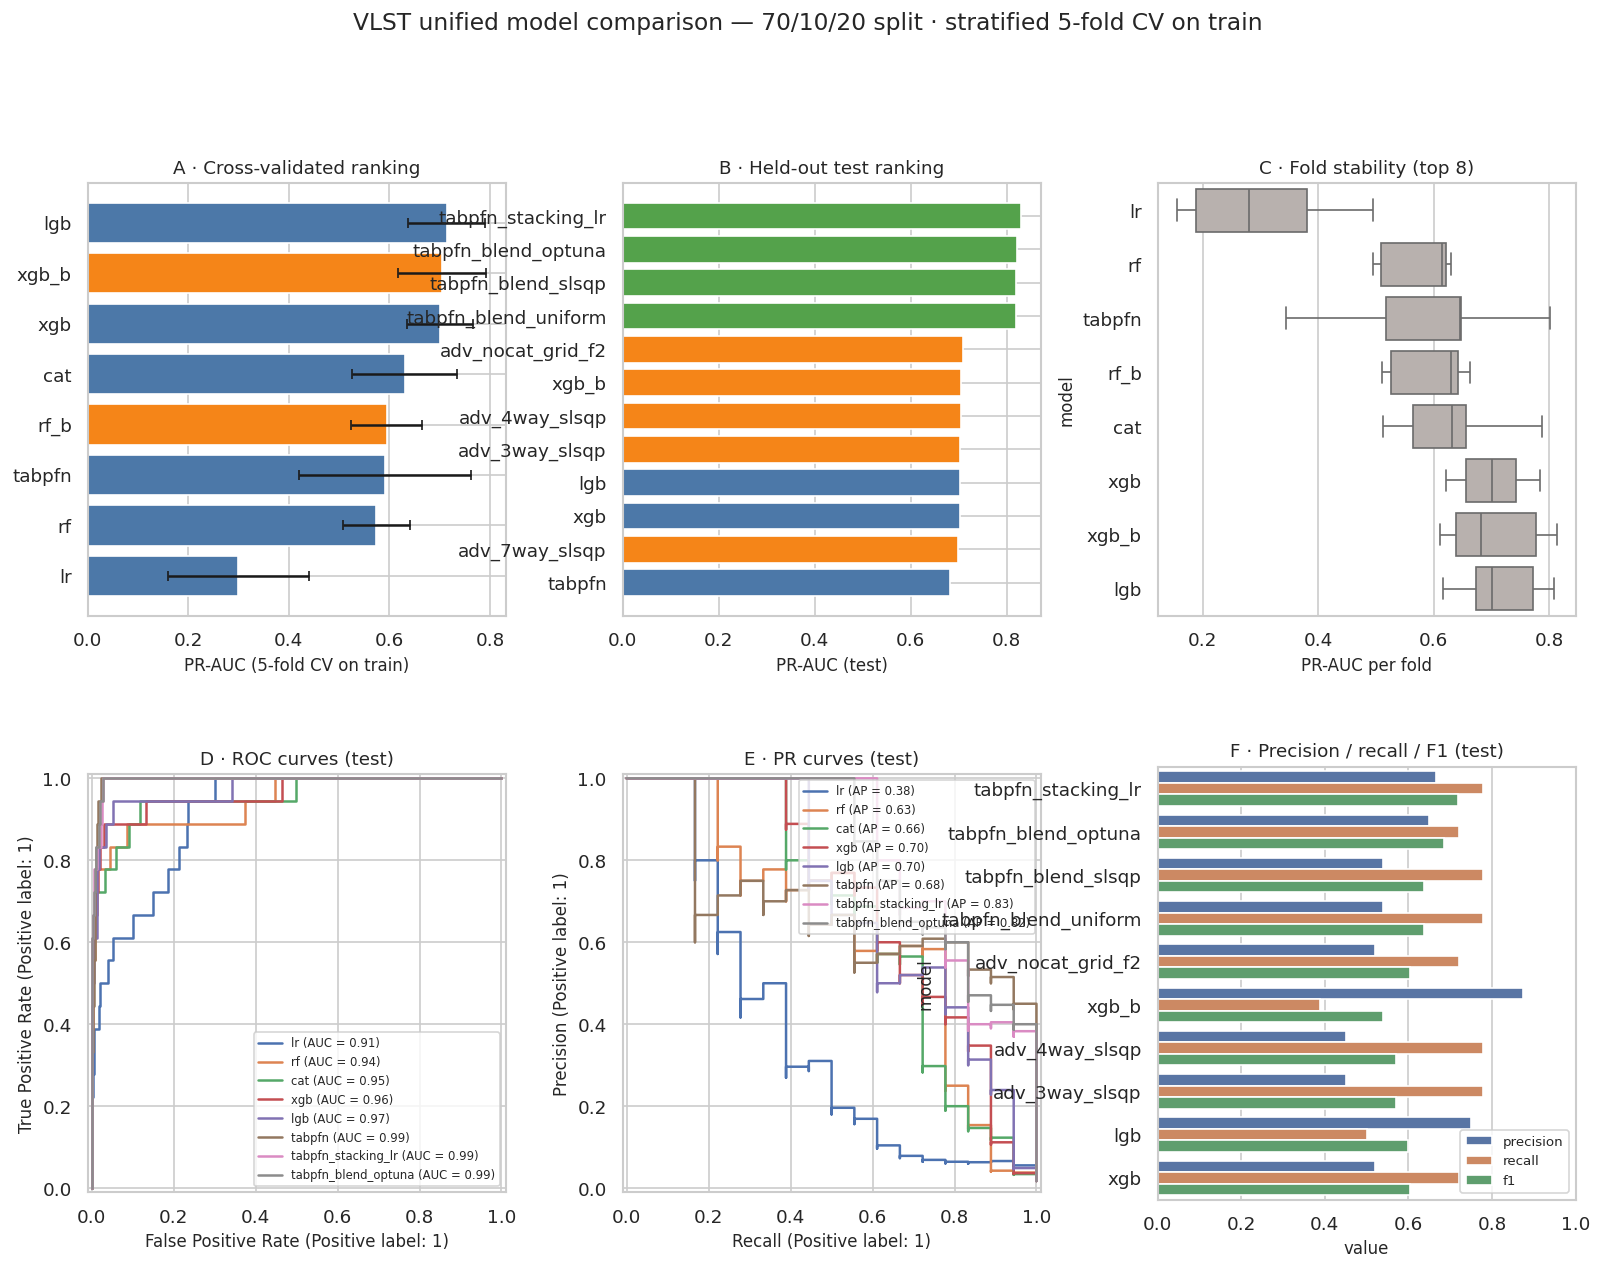

Saved figure: /kaggle/working/modeling_results/results_comparison_panels.png


In [11]:
palette = {"baseline": "#4C78A8", "advanced": "#F58518", "tabpfn": "#54A24B"}
top_models = test_leaderboard.head(10)["model"].tolist()
baseline_keep = [m for m in (["lr", "rf", "cat", "xgb", "lgb"] + (["tabpfn"] if TABPFN_AVAILABLE else []))]
curve_models = list(dict.fromkeys(baseline_keep + [m for m in top_models if m not in baseline_keep]))[:8]

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.28)

# Panel A — Test PR-AUC (primary ranking)
ax_a = fig.add_subplot(gs[0, 0])
plot_test = test_leaderboard.sort_values("pr_auc", ascending=True).tail(12)
colors_a = [palette.get(f, "#888") for f in plot_test["family"]]
ax_a.barh(plot_test["model"], plot_test["pr_auc"], color=colors_a)
ax_a.set_xlabel("PR-AUC (30% test · tabpfn.ipynb split)")
ax_a.set_title("A · Test ranking (PR-AUC)")

# Panel B — Classical CV only (TabPFN excluded)
ax_b = fig.add_subplot(gs[0, 1])
plot_cv = cv_summary.sort_values("pr_auc_mean", ascending=True)
colors_b = [palette.get(f, "#888") for f in plot_cv["family"]]
ax_b.barh(plot_cv["model"], plot_cv["pr_auc_mean"], xerr=plot_cv["pr_auc_std"], color=colors_b, capsize=3)
ax_b.set_xlabel("PR-AUC (5-fold CV on train)")
ax_b.set_title("B · Classical CV (trees/boosters)")

# Panel C — TabPFN OOF-on-train vs test
ax_c = fig.add_subplot(gs[0, 2])
if TABPFN_AVAILABLE and tabpfn_oof_diag:
    ax_c.bar([0], [tabpfn_oof_diag["oof_pr_auc_train"]], width=0.35, label="OOF train")
    ax_c.bar([1], [float(test_leaderboard.loc[test_leaderboard["model"]=="tabpfn", "pr_auc"].iloc[0])], width=0.35, label="test")
    ax_c.set_xticks([0, 1]); ax_c.set_xticklabels(["tabpfn OOF", "tabpfn test"])
    ax_c.legend(fontsize=8)
else:
    ax_c.text(0.5, 0.5, "TabPFN N/A", ha="center", va="center")
ax_c.set_title("C · TabPFN diagnostic")

# Panel D — ROC curves on test
ax_d = fig.add_subplot(gs[1, 0])
for name in curve_models:
    if name in blend_specs:
        scores = blend_specs[name]["scores_test"]
    else:
        scores = P_test[name]
    RocCurveDisplay.from_predictions(y_test, scores, ax=ax_d, name=name)
ax_d.set_title("D · ROC curves (test)")
ax_d.legend(fontsize=7, loc="lower right")

# Panel E — PR curves on test
ax_e = fig.add_subplot(gs[1, 1])
for name in curve_models:
    if name in blend_specs:
        scores = blend_specs[name]["scores_test"]
    else:
        scores = P_test[name]
    PrecisionRecallDisplay.from_predictions(y_test, scores, ax=ax_e, name=name)
ax_e.set_title("E · PR curves (test)")
ax_e.legend(fontsize=7, loc="upper right")

# Panel F — Operational metrics at tuned threshold (test, top 10)
ax_f = fig.add_subplot(gs[1, 2])
ops = test_leaderboard.head(10).melt(
    id_vars=["model", "family"], value_vars=["precision", "recall", "f1"], var_name="metric", value_name="value"
)
sns.barplot(data=ops, y="model", x="value", hue="metric", ax=ax_f)
ax_f.set_xlim(0, 1)
ax_f.set_title("F · Precision / recall / F1 (test)")
ax_f.legend(fontsize=8, loc="lower right")

fig.suptitle("VLST unified model comparison — 70/30 split (tabpfn-aligned) · 5-fold CV on train", fontsize=14, y=1.01)
fig.savefig(RESULT_DIR / "results_comparison_panels.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", RESULT_DIR / "results_comparison_panels.png")

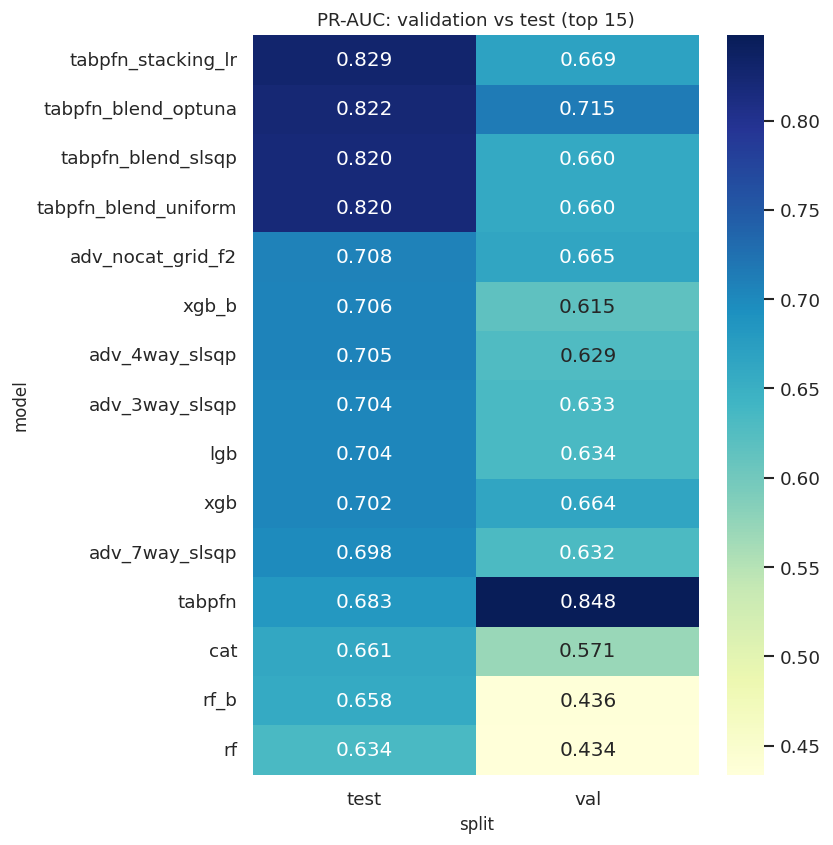

{
  "split": {
    "train": 0.7,
    "val": 0.1,
    "test": 0.2
  },
  "cv_folds": 5,
  "random_state": 42,
  "n_train": 3629,
  "n_val": 519,
  "n_test": 1037,
  "tabpfn_ran": true,
  "optuna_ran": true,
  "top_test_model": "tabpfn_stacking_lr",
  "top_test_pr_auc": 0.8293059283354172
}


In [12]:
# Supplementary heatmap — all splits × key metrics
heat_metrics = ["pr_auc", "roc_auc", "f1", "recall", "precision"]
heat = results.pivot_table(index="model", columns="split", values="pr_auc")
heat = heat.loc[test_leaderboard["model"].head(15)]

fig2, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("PR-AUC: cal vs test (top 15)")
fig2.savefig(RESULT_DIR / "results_pr_auc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

manifest = {
    "split": {"train": 1.0 - TEST_SIZE, "test": TEST_SIZE, "cal_from_train": FRAC_CAL},
    "threshold_cv_splits_tabpfn": THRESHOLD_CV_SPLITS,
    "cv_folds": N_CV_FOLDS,
    "random_state": RANDOM_STATE,
    "n_train": int(len(y_train)),
    "n_fit": int(len(y_fit)),
    "n_cal": int(len(y_cal)),
    "n_test": int(len(y_test)),
    "test_positives": int((y_test == 1).sum()),
    "tabpfn_ran": TABPFN_AVAILABLE,
    "optuna_ran": OPTUNA_AVAILABLE,
    "tabpfn_test_pr_auc": (
        float(test_leaderboard.loc[test_leaderboard["model"] == "tabpfn", "pr_auc"].iloc[0])
        if TABPFN_AVAILABLE and "tabpfn" in test_leaderboard["model"].values else None
    ),
    "tabpfn_oof_pr_auc_train": tabpfn_oof_diag["oof_pr_auc_train"] if tabpfn_oof_diag else None,
    "top_test_model": test_leaderboard.iloc[0]["model"],
    "top_test_pr_auc": float(test_leaderboard.iloc[0]["pr_auc"]),
}
with open(RESULT_DIR / "results_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))